# The task consists in adding colors to a grayscale image, knowing the mean intensity of red, green and blue in the expected image.

 ## Libraries - GPU test - GDOWN - Environment Settings:

Including all the libraries needed

In [ ]:
# Standard libraries
import os
import math
import random
import warnings
import sys, time
import pandas as pd

# Scientific libraries
import numpy as np
import matplotlib.pyplot as plt
from skimage.color import rgb2lab, lab2rgb

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import mixed_precision
from tensorflow.keras import layers as KL, models

# Torch (if needed)
import torch

# TensorFlow Datasets
import tensorflow_datasets as tfds

# Google Colab (Drive integration)
from google.colab import drive


Some parameters for the envinroment

In [ ]:
# === CONFIGURATION ===
IMG_SIZE = 128
BATCH_SIZE = 32

# Model base width
BASE = 40

GPU test

In [ ]:
gpu_avail = torch.cuda.is_available()
print(f"Is the GPU available? {gpu_avail}")

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Device: {device}")

Is the GPU available? True
Device: cuda


GDOWN connection

In [ ]:
!pip install gdown
import gdown

!gdown 1ij-JYS8N1ktuoklAbQYrFfOmR7e8xa1L

Downloading...
From: https://drive.google.com/uc?id=1ij-JYS8N1ktuoklAbQYrFfOmR7e8xa1L
To: /content/colorizer.weights.h5
100% 36.9M/36.9M [00:00<00:00, 63.1MB/s]


## Dataset

For this experiment, we the Oxford Flowers 102 dataset, which is a fine-grained image classification dataset containing 102 categories of flowers.  It consists of 8,189 images in total.

**Preprocess image** : resizing and normalization

In [ ]:
def preprocess_image(sample):
    """Resize and normalize image"""
    image = tf.image.resize(sample['image'], (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image

We define a **GrayScale Generator**, yielding batches of color images along with their grayscale versions and average color palettes.

In [ ]:
# === DATA GENERATOR ===
class GrayScaleGenerator(tf.keras.utils.Sequence):
    def __init__(self, images, batch_size=BATCH_SIZE, shuffle=True):
        self.images = images.numpy() # Convert to numpy array
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(len(images))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return len(self.images) // self.batch_size

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_color = self.images[batch_indices]
        batch_gray = np.mean(batch_color,axis=-1)
        batch_palette = np.mean(batch_color,axis=(1,2))
        return (batch_gray, batch_palette), batch_color

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

**Load and splitters**: the dataset is divided into train (80%), validation (10%) and test(10%) using the following function.

In [ ]:
def load_flower_dataset_splits():
    base = "train+validation+test"

    ds_train = tfds.load(
        'oxford_flowers102',
        split=f'{base}[:80%]',
        shuffle_files=True,
        read_config=tfds.ReadConfig(shuffle_seed=42)
    )
    ds_val = tfds.load(
        'oxford_flowers102',
        split=f'{base}[80%:90%]',
        shuffle_files=True,
        read_config=tfds.ReadConfig(shuffle_seed=42)
    )
    ds_test = tfds.load(
        'oxford_flowers102',
        split=f'{base}[90%:]',
        shuffle_files=True,
        read_config=tfds.ReadConfig(shuffle_seed=42)
    )

    ds_train = tf.stack(list(ds_train.map(preprocess_image)))
    ds_val   = tf.stack(list(ds_val.map(preprocess_image)))
    ds_test  = tf.stack(list(ds_test.map(preprocess_image)))

    print("[Flowers102 80/10/10]")
    print(f"  train: {ds_train.shape[0]} images")
    print(f"  val:   {ds_val.shape[0]} images")
    print(f"  test:  {ds_test.shape[0]} images")
    print(f"  image shape: {ds_train.shape[1:]}  dtype={ds_train.dtype}")

    return (ds_train, ds_val, ds_test)


Creating generators with the previously defined functions

In [ ]:

train_imgs, val_imgs, test_imgs = load_flower_dataset_splits()

train_rgb = GrayScaleGenerator(train_imgs, batch_size=BATCH_SIZE)
val_rgb = GrayScaleGenerator(val_imgs, batch_size=BATCH_SIZE)
test_rgb = GrayScaleGenerator(test_imgs, batch_size=BATCH_SIZE)



Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

...

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_flowers102/incomplete.WLDLLP_2.1.1/oxford_flowers102-test.tfrecord*…

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_flowers102/incomplete.WLDLLP_2.1.1/oxford_flowers102-validation.tfr…

Dataset oxford_flowers102 downloaded and prepared to /root/tensorflow_datasets/oxford_flowers102/2.1.1. Subsequent calls will reuse this data.
[Flowers102 80/10/10]
  train: 6959 images
  val:   2655 images
  test:  2655 images
  image shape: (128, 128, 3)  dtype=<dtype: 'float32'>


# Baseline
We define a simple baseline, where we uniformly distribute colors according to the given input palette.

In [ ]:
def baseline(gray,palette):
  m = np.mean(gray, axis=(1,2))
  red = gray*(palette[:,0]/m)[:, np.newaxis, np.newaxis]
  green = gray*(palette[:,1]/m)[:, np.newaxis, np.newaxis]
  blue = gray*(palette[:,2]/m)[:, np.newaxis, np.newaxis]
  return np.stack([red,green,blue],axis=-1)

1
Batch index: 1, Sample index: 23
(1, 128, 128) (1, 3) (1, 128, 128, 3)


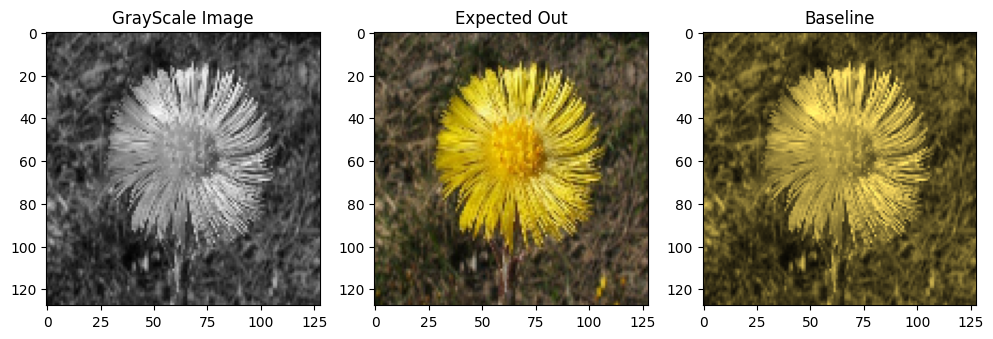

In [ ]:
#visualization
# Choose a random batch and sample index
bidx = np.random.randint(low=0, high=len(test_rgb)//32)
print(bidx)
(gray_batch, palette_batch), rgb_true_batch = test_rgb[bidx]
B = gray_batch.shape[0]
iidx = np.random.randint(low=0, high=B)
print(f"Batch index: {bidx}, Sample index: {iidx}")

# Extract single sample
x_gray = gray_batch[iidx:iidx+1, ...]
x_palette  = palette_batch[iidx:iidx+1, ...]
y = rgb_true_batch[iidx:iidx+1, ...]

baseline_out = baseline(x_gray,x_palette)
print(x_gray.shape, x_palette.shape, y.shape)

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(x_gray[0],cmap='gray')
plt.title("GrayScale Image")

plt.subplot(1, 3, 2)
plt.imshow(y[0])
plt.title("Expected Out")

plt.subplot(1, 3, 3)
plt.imshow(baseline_out[0])
plt.title("Baseline")
plt.show()


## MODEL

This model is a **U-Net-like convolutional network** designed for image colorization. It takes as input a grayscale image and a global color palette vector, and outputs the reconstructed RGB image. The encoder progressively extracts features through convolutional blocks and downsampling, while the decoder upsamples and reuses encoder features via skip connections to recover details.

The model optionally integrates **FiLM (Feature-wise Linear Modulation)** as an additional conditioning mechanism. FiLM works by generating scaling (gamma) and shifting (beta) parameters from the palette vector, and applying them to the feature maps as
$$
y = (1 + \gamma) \cdot x + \beta
$$


This allows the model to *inject global color information into intermediate representations*, guiding the network to produce more consistent and realistic colorizations.

- **Inputs:** one grayscale image $(H, W, 1)$ and one palette vector $(3,)$. The palette can optionally be tiled and concatenated to the grayscale input.  
- **Encoder:** sequence of *down_blocks* with Conv–BN–ReLU layers, FiLM modulation, and MaxPooling. Each stage stores a **skip connection** to preserve spatial information.  
- **Bottleneck:** deepest feature representation, enriched with FiLM conditioning from the palette.  
- **Decoder:** *up_blocks* that upsample the features, concatenate the corresponding skip connections from the encoder, apply convolutions, and optionally FiLM to refine details.  
- **Output:** a reconstructed RGB image $(H, W, 3)$ with values in $[0,1]$ using sigmoid activation.


In [ ]:
# FiLM modulation: y = (1 + gamma) * x + beta
def film(x, pal, channels, name=None):
    gamma = KL.Dense(channels, activation=None, name=None if name is None else name + "_gamma")(pal)
    beta  = KL.Dense(channels, activation=None, name=None if name is None else name + "_beta")(pal)
    gamma = KL.Reshape((1, 1, channels), name=None if name is None else name + "_gamma_rs")(gamma)
    beta  = KL.Reshape((1, 1, channels),  name=None if name is None else name + "_beta_rs")(beta)
    scale = KL.Lambda(lambda t: t + 1.0, name=None if name is None else name + "_scale")(gamma)
    x = KL.Multiply(name=None if name is None else name + "_mul")([x, scale])
    x = KL.Add(name=None if name is None else name + "_add")([x, beta])
    return x

# Double Conv2D block with BatchNorm + ReLU
def conv_block(x, filters, k=3, name=None):
    x = KL.Conv2D(filters, k, padding="same", use_bias=False, name=None if name is None else name + "_conv1")(x)
    x = KL.BatchNormalization(name=None if name is None else name + "_bn1")(x)
    x = KL.Activation("relu", name=None if name is None else name + "_act1")(x)

    x = KL.Conv2D(filters, k, padding="same", use_bias=False, name=None if name is None else name + "_conv2")(x)
    x = KL.BatchNormalization(name=None if name is None else name + "_bn2")(x)
    x = KL.Activation("relu", name=None if name is None else name + "_act2")(x)
    return x

# Encoder block: Conv + FiLM + MaxPool
def down_block(x, pal, filters, use_film=True, name=None):
    x = conv_block(x, filters, name=None if name is None else name + "_conv")
    if use_film:
        x = film(x, pal, filters, name=None if name is None else name + "_film")
    skip = x
    x = KL.MaxPooling2D(name=None if name is None else name + "_pool")(x)
    return x, skip

# Decoder block: Upsample + Concatenate skip + Conv + FiLM
def up_block(x, skip, pal, filters, use_film=True, name=None):
    x = KL.UpSampling2D(name=None if name is None else name + "_up")(x)
    x = KL.Concatenate(name=None if name is None else name + "_cat")([x, skip])
    x = conv_block(x, filters, name=None if name is None else name + "_conv")
    if use_film:
        x = film(x, pal, filters, name=None if name is None else name + "_film")
    return x

# Palette tiling
def palette_map(pal, ref, name=None):
    def _tile(args):
        p, r = args
        h = tf.shape(r)[1]; w = tf.shape(r)[2]
        p = tf.reshape(p, (-1, 1, 1, 3))
        return tf.tile(p, [1, h, w, 1])
    return KL.Lambda(_tile, name=name)([pal, ref])

# Build UNet with FiLM conditioning
def build_unet_film_rgb(img_size=128, base=40, depth=3, use_film=True, use_palette_map=True):
    inp_gray = KL.Input((img_size, img_size, 1), name="gray_input")
    inp_pal  = KL.Input((3,), name="palette_input")

    x0 = inp_gray
    if use_palette_map:
        pmap = palette_map(inp_pal, inp_gray, name="palette_map")
        x0 = KL.Concatenate(name="gray_plus_palette")([inp_gray, pmap])

    skips = []
    x = x0
    f = base
    for d in range(depth):
        x, skip = down_block(x, inp_pal, f, use_film=use_film, name=f"enc{d+1}")
        skips.append(skip)
        f *= 2

    x = conv_block(x, f, name="bottleneck_conv")
    if use_film:
        x = film(x, inp_pal, f, name="bottleneck_film")

    for d in reversed(range(depth)):
        f //= 2
        x = up_block(x, skips[d], inp_pal, f, use_film=use_film, name=f"dec{depth-d}")

    out = KL.Conv2D(3, 1, activation="sigmoid", name="rgb_out")(x)
    return models.Model([inp_gray, inp_pal], out, name="UNet_FiLM_RGB_3M")


In [ ]:
tf.keras.backend.clear_session()
model = build_unet_film_rgb(img_size=IMG_SIZE, base=BASE, depth=3, use_film=True, use_palette_map=True)
model.summary()

Model: "UNet_FiLM_RGB_3M"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ gray_input          │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ palette_input       │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ palette_map         │ (None, 128, 128,  │          0 │ palette_input[0]… │
│ (Lambda)            │ 3)                │            │ gray_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gray_plus_palette   │ (None, 128, 128,  │          0 │ gray_input[0][0], │
│ (Concatenate)       │ 4)                │            │ palette_map[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_conv_conv1     │ (None, 128, 128,  │      1,440 │ gray_plus_palett… │
│ (Conv2D)            │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_conv_bn1       │ (None, 128, 128,  │        160 │ enc1_conv_conv1[… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_conv_act1      │ (None, 128, 128,  │          0 │ enc1_conv_bn1[0]… │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_conv_conv2     │ (None, 128, 128,  │     14,400 │ enc1_conv_act1[0… │
│ (Conv2D)            │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_film_gamma     │ (None, 40)        │        160 │ palette_input[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_conv_bn2       │ (None, 128, 128,  │        160 │ enc1_conv_conv2[… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_film_gamma_rs  │ (None, 1, 1, 40)  │          0 │ enc1_film_gamma[… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_conv_act2      │ (None, 128, 128,  │          0 │ enc1_conv_bn2[0]… │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_film_scale     │ (None, 1, 1, 40)  │          0 │ enc1_film_gamma_… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_film_beta      │ (None, 40)        │        160 │ palette_input[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_film_mul       │ (None, 128, 128,  │          0 │ enc1_conv_act2[0… │
│ (Multiply)          │ 40)               │            │ enc1_film_scale[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_film_beta_rs   │ (None, 1, 1, 40)  │          0 │ enc1_film_beta[0… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_film_add (Add) │ (None, 128, 128,  │          0 │ enc1_film_mul[0]

 Total params: 3,054,043 (11.65 MB)

 Trainable params: 3,050,523 (11.64 MB)

 Non-trainable params: 3,520 (13.75 KB)

### Loss Functions


**MAE + MSE:** combines Mean Absolute Error and Mean Squared Error with adjustable weights. It balances robustness to outliers (MAE) and sensitivity to larger deviations (MSE).


In [ ]:
def mae_mse_loss(alpha=0.5, beta=0.5):
    """
    Combination of MAE and MSE.
    Args:
        alpha (float): Weight for MAE component (default 0.5).
        beta  (float): Weight for MSE component (default 0.5).
    """
    mae = tf.keras.losses.MeanAbsoluteError(reduction=tf.keras.losses.Reduction.SUM_OVER_BATCH_SIZE)
    mse = tf.keras.losses.MeanSquaredError(reduction=tf.keras.losses.Reduction.SUM_OVER_BATCH_SIZE)

    def loss(y_true, y_pred):
        return alpha * mae(y_true, y_pred) + beta * mse(y_true, y_pred)
    return loss

### Functions for tests and plots:

The following function allows to plot the history of training:

In [ ]:
def plot_train_val_loss(history, title="Training vs Validation Loss"):
    """
    Plot training and validation loss curves from a Keras History object.

    """
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], label='Train Loss')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


The following functions are used to test the model after training.

In [ ]:
import numpy as np, sys, time

def test_model(model, test_gen, eps=1e-12, max_batches=None, progress_every=10):
    mse_model_per_img_list = []
    mse_base_per_img_list  = []
    ratio_per_img_list     = []
    n_images = 0

    n_batches = len(test_gen)
    if max_batches is not None:
        n_batches = min(n_batches, int(max_batches))

    t0 = time.time()
    for i in range(n_batches):
        (x_gray, x_pal), y_true = test_gen[i]
        if x_gray.shape[0] == 0:
            continue

        # Forward pass
        y_pred = model([x_gray, x_pal], training=False)
        if hasattr(y_pred, "numpy"):
            y_pred = y_pred.numpy()
        y_base = baseline(x_gray, x_pal)

        # --- MSE per image
        m_mse_img = np.mean((y_pred - y_true) ** 2, axis=(1, 2))
        b_mse_img = np.mean((y_base - y_true) ** 2, axis=(1, 2))

        # Ratio per immagine
        r_img = m_mse_img / (b_mse_img + eps)

        mse_model_per_img_list.append(m_mse_img)
        mse_base_per_img_list.append(b_mse_img)
        ratio_per_img_list.append(r_img)
        n_images += x_gray.shape[0]

        # Progress bar
        if progress_every and ((i + 1) % progress_every == 0 or (i + 1) == n_batches):
            elapsed = time.time() - t0
            sys.stdout.write(f"\rTest batch {i+1}/{n_batches} - elapsed {elapsed:.1f}s")
            sys.stdout.flush()

    if n_images == 0:
        raise RuntimeError("No valid images found in the test set. Check the generator (__len__/__getitem__).")

    # Concat
    mse_model_per_img = np.concatenate(mse_model_per_img_list, axis=0)  # (N,)
    mse_base_per_img  = np.concatenate(mse_base_per_img_list,  axis=0)  # (N,)
    ratio_per_img     = np.concatenate(ratio_per_img_list,     axis=0)  # (N,)

    # mean of ratios
    ratio_mean = float(np.mean(ratio_per_img))
    ratio_std  = float(np.std(ratio_per_img, ddof=1))

    mse_model_mean = float(np.mean(mse_model_per_img))
    mse_base_mean  = float(np.mean(mse_base_per_img))
    mse_model_std  = float(np.std(mse_model_per_img, ddof=1))
    mse_base_std   = float(np.std(mse_base_per_img,  ddof=1))

    print()


    print(f"FINAL SCORE: Mean ratio (model/base): {ratio_mean:.6f}")
    print(f"FINAL SCORE: Std  ratio (model/base): {ratio_std:.6f}")
    print(f"Mean MSE (model)   : {mse_model_mean:.6f}")
    print(f"Mean MSE (baseline): {mse_base_mean:.6f}")
    print(f"Std MSE (model)    : {mse_model_std:.6f}")
    print(f"Std MSE (baseline) : {mse_base_std:.6f}")
    print(f"Number of images   : {n_images}")


    mse_model_all = np.repeat(mse_model_per_img[:, None], 3, axis=1)  # (N,3)
    mse_base_all  = np.repeat(mse_base_per_img[:,  None], 3, axis=1)  # (N,3)
    ratios_all    = np.repeat(ratio_per_img[:,     None], 3, axis=1)  # (N,3)

    return {
        "mse_model_all": mse_model_all,
        "mse_base_all":  mse_base_all,
        "ratios_all":    ratios_all,
        "mse_model_per_img": mse_model_per_img,
        "mse_base_per_img":  mse_base_per_img,
        "ratio_per_img":     ratio_per_img,
    }


## Training

Google drive connectivity to store the best model parameters

In [ ]:
# 1) Mount Google Drive
drive.mount('/content/drive')

# 2) Choose a folder in Drive where model weights will be saved
SAVE_DIR = '/content/drive/MyDrive/Colorizer'
os.makedirs(SAVE_DIR, exist_ok=True)

# 3) Paths for checkpoints
CKPT_PATH_1 = os.path.join(SAVE_DIR, 'backup_RGB_best_colorizer_1.weights.h5')
CKPT_PATH_2 = os.path.join(SAVE_DIR, 'backup_RGB_best_colorizer_2.weights.h5')


**Compilation and Training**  

We use the **Adam optimizer**.  

The following callbacks are used:  
- **ReduceLROnPlateau:** automatically reduces the learning rate when the validation loss stops improving, helping the optimizer escape plateaus and converge better.  
- **EarlyStopping:** monitors the validation loss and stops training if no improvement is observed after a certain number of epochs, thus avoiding overfitting and saving computation time (training stopped at epoch 63 out of 200).  
- **ModelCheckpoint:** saves the model weights at the epoch where the validation loss reaches its minimum.



In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(3e-4),
    loss=mae_mse_loss(alpha=0.5, beta=0.5),   # MAE+MSE
    metrics=[tf.keras.metrics.MeanAbsoluteError(name='mae'),
             tf.keras.metrics.MeanSquaredError(name='mse')]
)

In [ ]:
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',    # minimize loss
        patience=3,
        factor=0.5,
        min_lr=1e-6,
        verbose=1,
        mode='min'
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=1,
        mode='min'
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=CKPT_PATH_1,
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=True,
        mode='min',
        verbose=1
    )
]

In [ ]:
history1 = model.fit(
    train_rgb,
    validation_data=val_rgb,
    epochs=200,
    callbacks=callbacks,
    verbose=1   #see progress
)

Epoch 1/200
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0277 - mae: 0.0500 - mse: 0.0053
Epoch 1: val_loss improved from 0.02771 to 0.02631, saving model to /content/drive/MyDrive/Colorizer/RGB_best_colorizer_1.weights.h5
217/217 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/step - loss: 0.0277 - mae: 0.0500 - mse: 0.0053 - val_loss: 0.0263 - val_mae: 0.0476 - val_mse: 0.0050 - learning_rate: 1.5000e-04
Epoch 2/200
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0274 - mae: 0.0495 - mse: 0.0052
Epoch 2: val_loss did not improve from 0.02631
217/217 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - loss: 0.0274 - mae: 0.0495 - mse: 0.0052 - val_loss: 0.0265 - val_mae: 0.0479 - val_mse: 0.0050 - learning_rate: 1.5000e-04
Epoch 3/200
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0273 - mae: 0.0493 - mse: 0.0052
Epoch 3: val_loss improved from 0.02631 to 0.02568, saving model to /content/drive/MyDrive/Colorizer/RGB_best_colorizer_1.weights.h5
217/217 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/step - loss: 0.0273 -

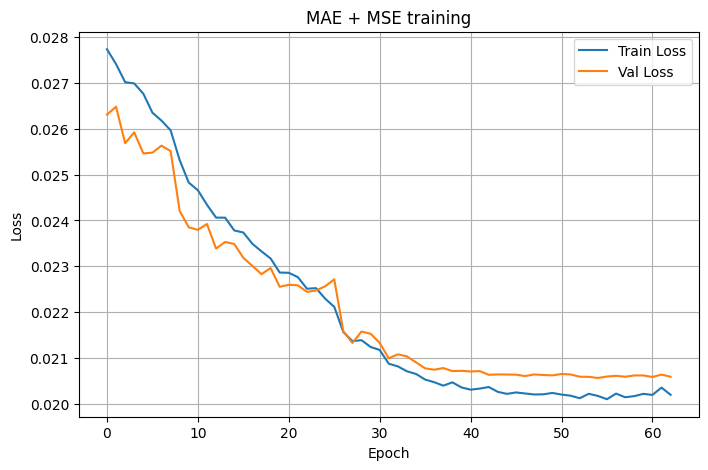

In [ ]:
plot_train_val_loss(history1, "MAE + MSE training")

Use the following code to rebuild the model architecture and load the saved weights (previously downloaded with gdown) corresponding to this training stage:


In [ ]:
model = build_unet_film_rgb(img_size=IMG_SIZE, base=40, depth=3, use_film=True, use_palette_map=True)
model.load_weights("colorizer.weights.h5")

Here I evaluate the trained model on the test set following the professor's protocol.  
The metrics reported are:  
- Mean and standard deviation of the MSE for both the model and the baseline.  
- Number of test images.  
- **Final score:** mean of the per-image MSE ratios (model vs baseline) and their standard deviation.  

In [ ]:
results = test_model(model_snap_1, test_rgb)  # completo


Test batch 82/82 - elapsed 12.2s
FINAL SCORE: Mean ratio (model/base): 0.523098
FINAL SCORE: Std  ratio (model/base): 0.515996
Mean MSE (model)   : 0.003295
Mean MSE (baseline): 0.009592
Std MSE (model)    : 0.003731
Std MSE (baseline) : 0.010612
Number of images   : 2624


This function selects a random sample from the test generator and visualizes the grayscale input, the baseline reconstruction, the prediction of model_snap_1, the prediction of model_snap_2 (FINAL MODEL), and the ground truth RGB image.

In [ ]:
def show_random_sample_rgb(test_gen, model, clip_rgb=True):
    # Choose a random batch and sample index
    bidx = np.random.randint(low=0, high=len(test_gen)//32)
    (gray_batch, palette_batch), rgb_true_batch = test_gen[bidx]
    B = gray_batch.shape[0]
    iidx = np.random.randint(low=0, high=B)

    # Extract single sample
    gray     = gray_batch[iidx:iidx+1, ...]
    palette  = palette_batch[iidx:iidx+1, ...]
    rgb_true = rgb_true_batch[iidx:iidx+1, ...]

    # Model predictions
    rgb_pred1 = model([gray, palette], training=False)

    # Baseline prediction
    rgb_base = baseline(gray, palette)

    # Optional clipping
    if clip_rgb:
        rgb_true  = np.clip(np.array(rgb_true),  0.0, 1.0)
        rgb_pred1 = np.clip(np.array(rgb_pred1), 0.0, 1.0)
        rgb_base  = np.clip(np.array(rgb_base),  0.0, 1.0)
    else:
        rgb_true  = np.array(rgb_true)
        rgb_pred1 = np.array(rgb_pred1)
        rgb_base  = np.array(rgb_base)

    # Fix grayscale shape for plotting
    H, W = rgb_true.shape[1:3]
    g = np.array(gray[0, ...])
    g = np.squeeze(g)
    if g.ndim == 0:
        g = np.full((H, W), float(g))
    elif g.ndim == 1:
        if g.shape[0] == H:
            g = g.reshape(H, 1).repeat(W, axis=1)
        elif g.shape[0] == W:
            g = g.reshape(1, W).repeat(H, axis=0)
        else:
            g = g.reshape(H, W)
    elif g.ndim == 3 and g.shape[-1] == 1:
        g = g[..., 0]

    # Squeeze RGB predictions
    rgb_t = rgb_true[0]
    rgb_p1 = rgb_pred1[0]
    rgb_b  = rgb_base[0]

    # Plot
    ncols = 4
    plt.figure(figsize=(3.4 * ncols, 3.2))
    plt.subplot(1, ncols, 1); plt.imshow(g, cmap='gray'); plt.title('Grayscale');    plt.axis('off')
    plt.subplot(1, ncols, 2); plt.imshow(rgb_b);           plt.title('Baseline');     plt.axis('off')
    plt.subplot(1, ncols, 3); plt.imshow(rgb_p1);          plt.title('Prediction'); plt.axis('off')
    plt.subplot(1, ncols, 4); plt.imshow(rgb_t);       plt.title('Ground Truth'); plt.axis('off')
    plt.tight_layout()
    plt.show()

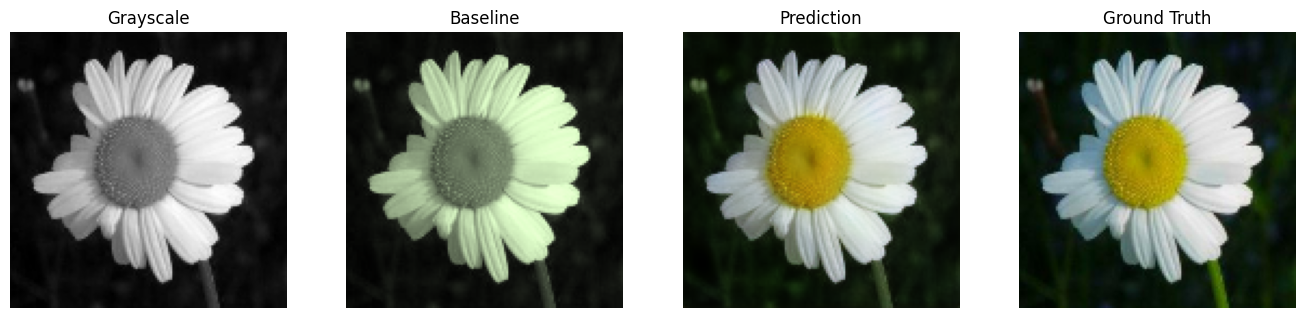

In [ ]:
show_random_sample_rgb(test_rgb, model)